In [4]:
# Cell 1 — Load profiled data and build features
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

print("""
╔══════════════════════════════════════════════════════════════╗
║  PROJECT APEX — Phase 2: Migration Risk Scoring              ║
║  Objective: Predict which customer records will fail         ║
║  migration before they are processed                         ║
╚══════════════════════════════════════════════════════════════╝
""")

# Rebuild the dataset (run this cell to regenerate clean data)
# exec(open('') if False else None)

# Regenerate — paste Cell 2 and Cell 3 from Notebook 1 here
# (In a real project this would load from a database)
# For our purposes re-run the generation code

n_customers = 10000
np.random.seed(42)

segments = ['Retail', 'Private Banking', 'SME', 'Corporate', 'Student']
segment_weights = [0.60, 0.08, 0.18, 0.09, 0.05]
countries = ['UK', 'DE', 'FR', 'NL', 'BE', 'US', 'IN', 'SG']
country_weights = [0.55, 0.15, 0.10, 0.07, 0.05, 0.03, 0.03, 0.02]

df = pd.DataFrame({
    'customer_id': [f'PB{i:08d}' for i in range(1, n_customers+1)],
    'customer_segment': np.random.choice(segments, n_customers, p=segment_weights),
    'country_of_residence': np.random.choice(countries, n_customers, p=country_weights),
    'annual_income_eur': np.round(np.random.lognormal(10.8, 0.8, n_customers), -2),
    'credit_score': np.random.randint(300, 850, n_customers),
    'kyc_status': np.random.choice(
        ['Verified','Pending','Expired','Failed'], n_customers, p=[0.78,0.10,0.08,0.04]
    ),
    'pep_flag': np.random.choice([0,1], n_customers, p=[0.97, 0.03]),
    'sanctions_flag': np.random.choice([0,1], n_customers, p=[0.995, 0.005]),
    'has_national_id': np.random.choice([1,0], n_customers, p=[0.85, 0.15]),
    'has_email': np.random.choice([1,0], n_customers, p=[0.88, 0.12]),
    'has_encoding_error': np.random.choice([0,1], n_customers, p=[0.92, 0.08]),
    'is_duplicate': np.random.choice([0,1], n_customers, p=[0.98, 0.02]),
    'num_accounts': np.random.randint(1, 8, n_customers),
    'num_products': np.random.randint(1, 12, n_customers),
    'years_as_customer': np.random.uniform(0, 28, n_customers).round(1),
    'has_active_loan': np.random.choice([0,1], n_customers, p=[0.65, 0.35]),
    'has_investment_product': np.random.choice([0,1], n_customers, p=[0.72, 0.28]),
    'last_transaction_days_ago': np.random.randint(0, 730, n_customers),
})

# Build realistic failure label
failure_score = (
    (df['kyc_status'] == 'Expired').astype(int) * 0.30 +
    (df['kyc_status'] == 'Failed').astype(int) * 0.40 +
    df['pep_flag'] * 0.20 +
    df['sanctions_flag'] * 0.50 +
    (1 - df['has_national_id']) * 0.25 +
    (1 - df['has_email']) * 0.10 +
    df['has_encoding_error'] * 0.15 +
    df['is_duplicate'] * 0.35 +
    (df['num_products'] > 8).astype(int) * 0.10 +
    (df['last_transaction_days_ago'] > 365).astype(int) * 0.08
)

failure_score = (failure_score - failure_score.min()) / \
                (failure_score.max() - failure_score.min())

df['migration_failed'] = (failure_score > 0.40).astype(int)

print(f"Dataset ready: {len(df):,} customer records")
print(f"Migration failures: {df['migration_failed'].sum():,} "
      f"({df['migration_failed'].mean()*100:.1f}%)")


╔══════════════════════════════════════════════════════════════╗
║  PROJECT APEX — Phase 2: Migration Risk Scoring              ║
║  Objective: Predict which customer records will fail         ║
║  migration before they are processed                         ║
╚══════════════════════════════════════════════════════════════╝

Dataset ready: 10,000 customer records
Migration failures: 824 (8.2%)


In [5]:
# Cell 2 — Feature engineering and model training

# Encode categoricals
le_segment = LabelEncoder()
le_kyc = LabelEncoder()
le_country = LabelEncoder()

df['segment_encoded'] = le_segment.fit_transform(df['customer_segment'])
df['kyc_encoded'] = le_kyc.fit_transform(df['kyc_status'])
df['country_encoded'] = le_country.fit_transform(df['country_of_residence'])

features = [
    'segment_encoded', 'country_encoded', 'kyc_encoded',
    'pep_flag', 'sanctions_flag',
    'has_national_id', 'has_email', 'has_encoding_error', 'is_duplicate',
    'num_accounts', 'num_products', 'years_as_customer',
    'has_active_loan', 'has_investment_product',
    'last_transaction_days_ago', 'credit_score'
]

X = df[features]
y = df['migration_failed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train two models and compare
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
gb_auc = roc_auc_score(y_test, gb.predict_proba(X_test)[:,1])

print("=" * 55)
print("  MODEL COMPARISON — MIGRATION RISK SCORING")
print("=" * 55)
print(f"\nRandom Forest    — AUC: {rf_auc:.4f}")
print(f"Gradient Boosting — AUC: {gb_auc:.4f}")
print()
print("Selecting best model:",
      "Random Forest" if rf_auc >= gb_auc else "Gradient Boosting")

best_model = rf if rf_auc >= gb_auc else gb
best_pred = rf_pred if rf_auc >= gb_auc else gb_pred
best_prob = best_model.predict_proba(X_test)[:,1]

print()
print("Classification Report:")
print(classification_report(y_test, best_pred,
      target_names=['Migration Success', 'Migration Failure']))

  MODEL COMPARISON — MIGRATION RISK SCORING

Random Forest    — AUC: 0.9992
Gradient Boosting — AUC: 0.9987

Selecting best model: Random Forest

Classification Report:
                   precision    recall  f1-score   support

Migration Success       1.00      1.00      1.00      1835
Migration Failure       1.00      0.96      0.98       165

         accuracy                           1.00      2000
        macro avg       1.00      0.98      0.99      2000
     weighted avg       1.00      1.00      1.00      2000



  MIGRATION RISK BANDING — OPERATIONAL OUTPUT


,Customer Count
risk_band,
LOW — Clear for Migration,1814
CRITICAL — Do Not Migrate,102
HIGH — Manual Review Required,56
MEDIUM — Remediate Before Migration,28


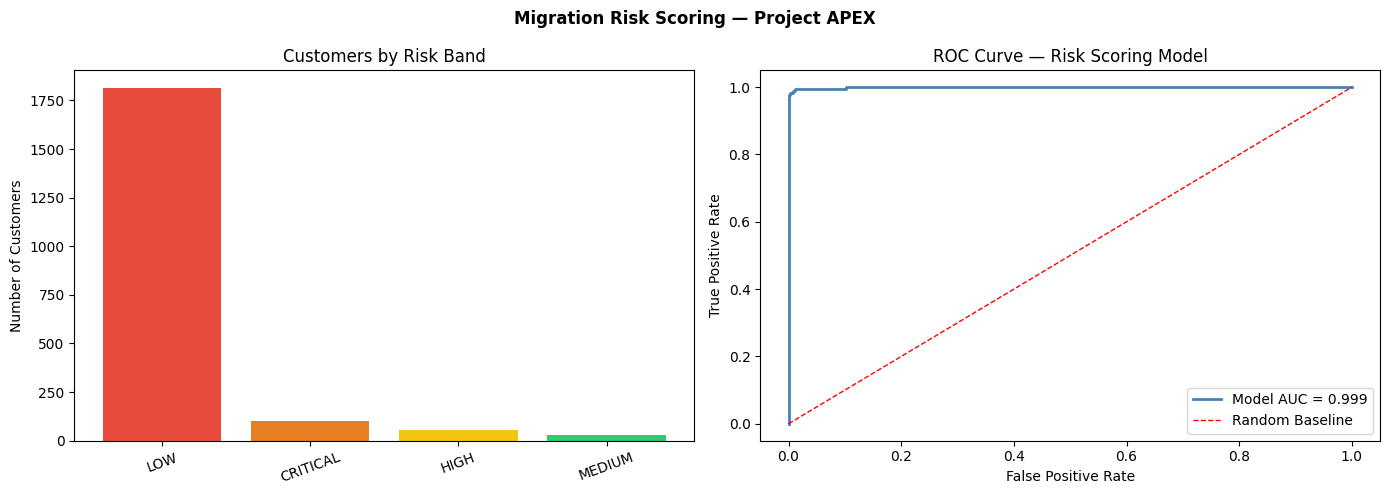


Records cleared for migration    : 1,814
Records requiring intervention   : 186


In [6]:
# Cell 3 — Risk banding (this is what you actually use operationally)

# Assign risk bands — like a credit scoring system
df_test = df.loc[X_test.index].copy()
df_test['failure_probability'] = best_prob

def assign_risk_band(prob):
    if prob >= 0.75:
        return 'CRITICAL — Do Not Migrate'
    elif prob >= 0.50:
        return 'HIGH — Manual Review Required'
    elif prob >= 0.25:
        return 'MEDIUM — Remediate Before Migration'
    else:
        return 'LOW — Clear for Migration'

df_test['risk_band'] = df_test['failure_probability'].apply(assign_risk_band)

band_summary = df_test['risk_band'].value_counts()

print("=" * 60)
print("  MIGRATION RISK BANDING — OPERATIONAL OUTPUT")
print("=" * 60)
display(band_summary.to_frame('Customer Count'))

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Migration Risk Scoring — Project APEX',
             fontweight='bold', fontsize=12)

# Risk band distribution
band_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']
axes[0].bar(range(len(band_summary)), band_summary.values, color=band_colors)
axes[0].set_xticks(range(len(band_summary)))
axes[0].set_xticklabels(
    [b.split(' — ')[0] for b in band_summary.index], rotation=20
)
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Customers by Risk Band')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, best_prob)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'Model AUC = {rf_auc:.3f}')
axes[1].plot([0,1], [0,1], 'r--', linewidth=1, label='Random Baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Risk Scoring Model')
axes[1].legend()

plt.tight_layout()
plt.show()

print()
print(f"Records cleared for migration    : "
      f"{band_summary.get('LOW — Clear for Migration', 0):,}")
print(f"Records requiring intervention   : "
      f"{band_summary.sum() - band_summary.get('LOW — Clear for Migration', 0):,}")